### Data Exploration

In [1]:
import pandas as pd

df = pd.read_csv("users.csv")

# Shape
print("Shape:", df.shape)



Shape: (208, 28)


In [2]:
# Column names
print("Columns:")
print(df.columns)



Columns:
Index(['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email',
       'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup',
       'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress',
       'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto',
       'role'],
      dtype='str')


In [3]:
# Data types
print("\nData Types:")
print(df.dtypes)




Data Types:
id              int64
firstName         str
lastName          str
maidenName        str
age             int64
gender            str
email             str
phone             str
username          str
password          str
birthDate         str
image             str
bloodGroup        str
height        float64
weight        float64
eyeColor          str
hair              str
ip                str
address           str
macAddress        str
university        str
bank              str
company           str
ein               str
ssn               str
userAgent         str
crypto            str
role              str
dtype: object


In [4]:
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())




Missing Values:
id              0
firstName       0
lastName        0
maidenName    148
age             0
gender          0
email           0
phone           0
username        0
password        0
birthDate       0
image           0
bloodGroup      0
height          0
weight          0
eyeColor        0
hair            0
ip              0
address         0
macAddress      0
university      0
bank            0
company         0
ein             0
ssn             0
userAgent       0
crypto          0
role            0
dtype: int64


In [5]:
# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())




Duplicate Rows:
0


In [6]:
# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
               id         age      height      weight
count  208.000000  208.000000  208.000000  208.000000
mean   104.500000   33.139423  175.720240   75.038606
std     60.188592    5.544269   14.119984   14.090775
min      1.000000   23.000000  150.250000   50.100000
25%     52.750000   29.000000  164.187500   62.547500
50%    104.500000   32.000000  177.430000   75.985000
75%    156.250000   36.000000  186.960000   86.992500
max    208.000000   46.000000  199.810000   99.540000


### Extract Nested Data (Country & City)
* The address column contains nested JSON. 

In [7]:
import ast

df['address'] = df['address'].apply(ast.literal_eval)

df['country'] = df['address'].apply(lambda x: x['country'])
df['city'] = df['address'].apply(lambda x: x['city'])

### Value Counts (Categorical Columns)

In [8]:
print("\nGender count:")
print(df['gender'].value_counts())

print("\nBlood Group count:")
print(df['bloodGroup'].value_counts())

print("\nEye Color count:")
print(df['eyeColor'].value_counts())

print("\nRole count:")
print(df['role'].value_counts())

print("\nCountry count:")
print(df['country'].value_counts())


Gender count:
gender
female    106
male      102
Name: count, dtype: int64

Blood Group count:
bloodGroup
O-     31
B-     31
AB+    29
AB-    29
B+     25
O+     22
A+     21
A-     20
Name: count, dtype: int64

Eye Color count:
eyeColor
Brown     35
Hazel     34
Green     28
Blue      24
Gray      24
Violet    22
Red       21
Amber     20
Name: count, dtype: int64

Role count:
role
user         193
moderator     10
admin          5
Name: count, dtype: int64

Country count:
country
United States    208
Name: count, dtype: int64


### Data Cleaning
* Handle missing values if any exist.

##

In [9]:
df['age'] = df['age'].fillna(df['age'].median())
df['height'] = df['height'].fillna(df['height'].mean())
df['weight'] = df['weight'].fillna(df['weight'].mean())

### Analysis

#### 1️. Average Age

In [10]:
print("Average Age:", df['age'].mean())

Average Age: 33.13942307692308


#### 2️. Average Age by Gender

In [11]:
print(df.groupby('gender')['age'].mean())

gender
female    31.377358
male      34.970588
Name: age, dtype: float64


#### 3️. Number of Users per Gender

In [12]:
print(df['gender'].value_counts())

gender
female    106
male      102
Name: count, dtype: int64


#### 4️. Top 10 Cities

In [13]:
print(df['city'].value_counts().head(10))

city
Phoenix         17
Dallas          15
Jacksonville    14
Los Angeles     14
Seattle         12
New York        11
Columbus        11
San Jose        11
Chicago         11
Philadelphia    11
Name: count, dtype: int64


#### 5️. Average Height & Weight

In [14]:
print("Average Height:", df['height'].mean())
print("Average Weight:", df['weight'].mean())

Average Height: 175.72024038461538
Average Weight: 75.03860576923077


#### 6. Is there any obvious relationship between age and height/weight?

In [15]:
print(df[['age','height','weight']].corr())

             age    height    weight
age     1.000000  0.023458  0.067026
height  0.023458  1.000000 -0.088655
weight  0.067026 -0.088655  1.000000


### Seaborn Visualizations

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Global Style
sns.set_theme(
    style="whitegrid",
    palette="Set2",
    font_scale=1.2
)

#### 1️. Age Distribution

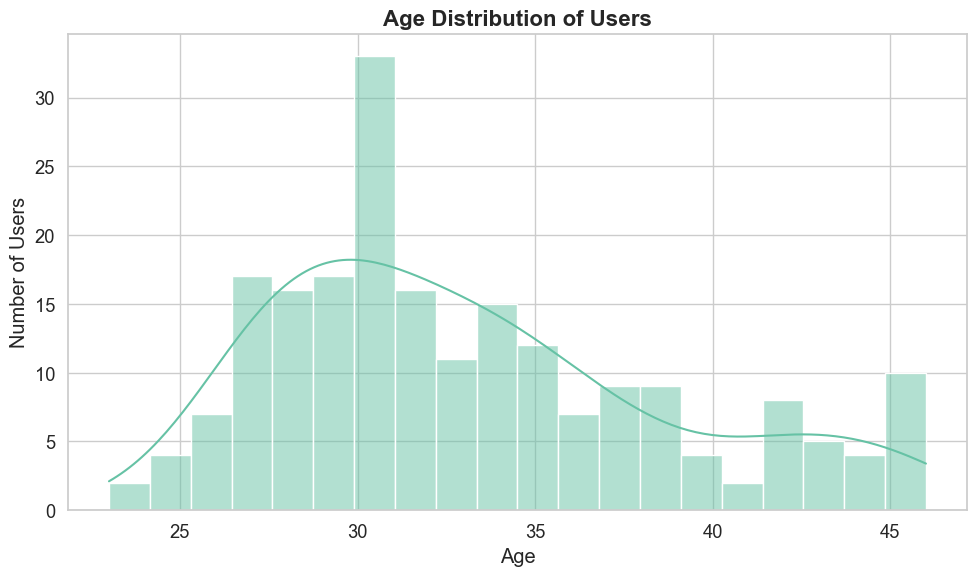

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution of Users", fontsize=16, weight='bold')
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

#### 2️. Users per Gender

C:\Users\boody\AppData\Local\Temp\ipykernel_5060\3579564120.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


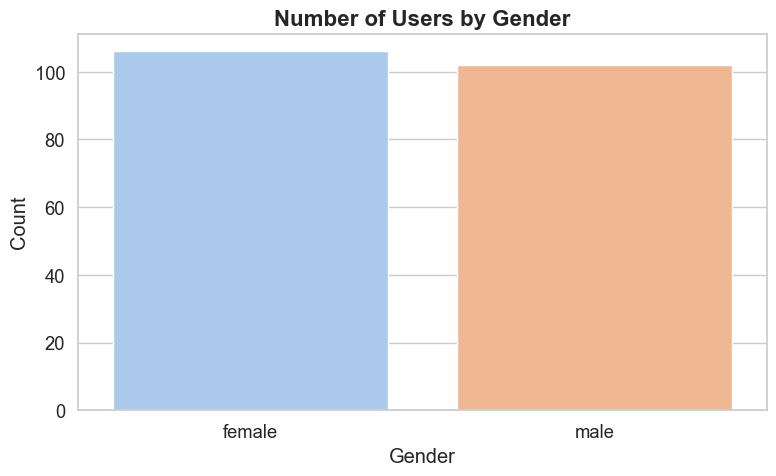

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="gender",
    palette="pastel"
)

plt.title("Number of Users by Gender", fontsize=16, weight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### 3️. Average Age by Gender

C:\Users\boody\AppData\Local\Temp\ipykernel_5060\164491328.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


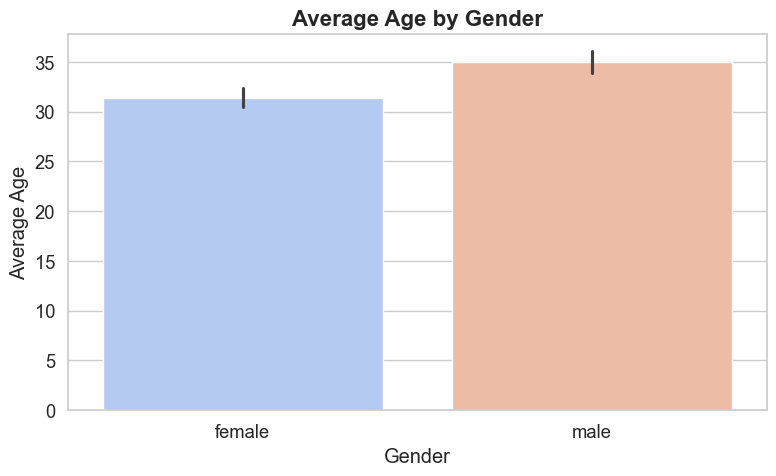

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="gender",
    y="age",
    palette="coolwarm"
)

plt.title("Average Age by Gender", fontsize=16, weight='bold')
plt.xlabel("Gender")
plt.ylabel("Average Age")

plt.tight_layout()
plt.show()

#### 4️. Age vs Height

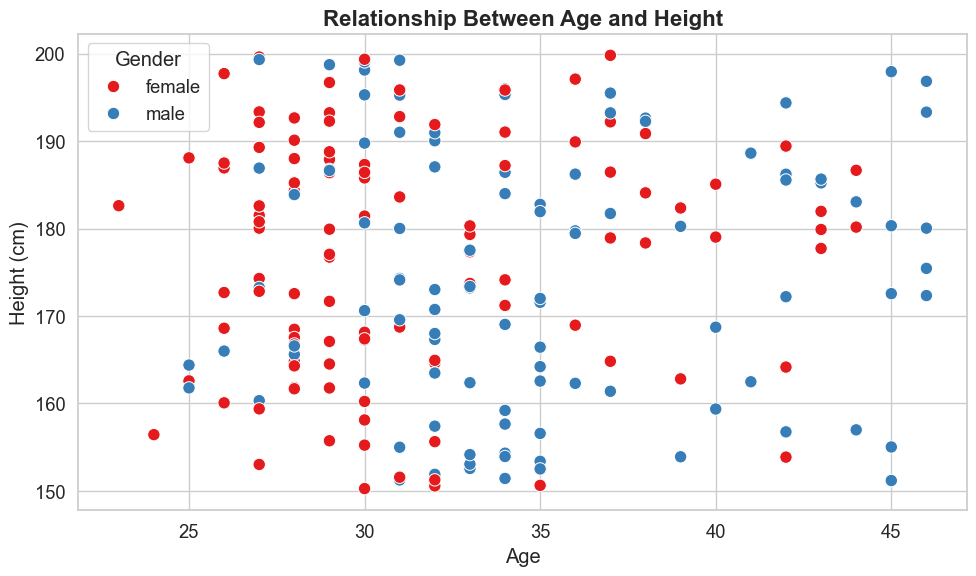

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="age",
    y="height",
    hue="gender",
    palette="Set1",
    s=80
)

plt.title("Relationship Between Age and Height", fontsize=16, weight='bold')
plt.xlabel("Age")
plt.ylabel("Height (cm)")

plt.legend(title="Gender")
plt.tight_layout()
plt.show()

#### 5️.Age vs Weight

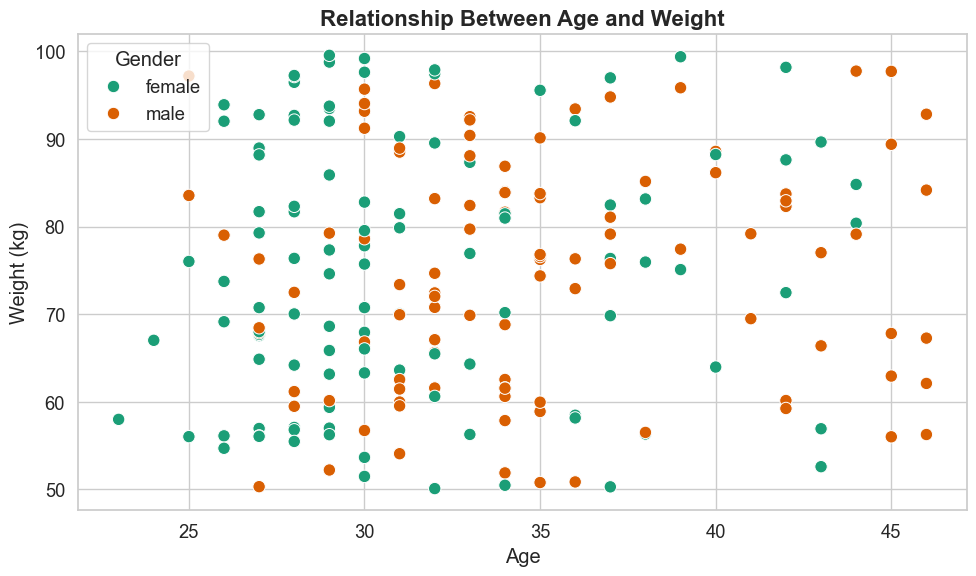

In [21]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="age",
    y="weight",
    hue="gender",
    palette="Dark2",
    s=80
)

plt.title("Relationship Between Age and Weight", fontsize=16, weight='bold')
plt.xlabel("Age")
plt.ylabel("Weight (kg)")

plt.legend(title="Gender")
plt.tight_layout()
plt.show()
